## **1. Import Library**

In [1]:
# Pastiin ini dijalanin dulu ya
#!pip install scikit-learn-extra
#!pip install "numpy<2"

In [2]:
# Library
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn_extra.cluster import KMedoids
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import classification_report

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **2. Memuat Dataset**

In [6]:
# Load dataset hasil processing
url = "https://drive.google.com/uc?id=15xk83k4FAHyJAjnK4eqTpyn6N9dHtyxZ"
data = pd.read_csv(url)

#Hapus Fitur tidak terpakai
data = data.drop('year_month', axis=1)
data = data[data['type_TRANSFER'] == False].copy()

expense = data[data['type_EXPENSE'] == True].copy().reset_index(drop=True)
income  = data[data['type_INCOME']  == True].copy().reset_index(drop=True)

print(f"Total (tanpa transfer): {len(data)}")
print(f"Expense: {len(expense)} baris | Income: {len(income)} baris")
data.head()


Total (tanpa transfer): 1111
Expense: 1008 baris | Income: 103 baris


,amount,year,month,day,category_Bills & Fees,category_Food & Drinks,category_Transport,account_Cash,account_Metro Card,account_Salary Bank,account_Savings Bank,type_EXPENSE,type_INCOME,type_TRANSFER
0,45000.0,2024,8,11,True,False,False,False,False,False,True,True,False,False
1,40000.0,2024,8,10,False,True,False,True,False,False,False,True,False,False
2,10000.0,2024,8,9,False,False,True,True,False,False,False,True,False,False
3,200000.0,2024,8,7,True,False,False,False,False,False,True,True,False,False
4,4000.0,2024,8,4,True,False,False,False,False,True,False,False,True,False


## **3. Membangun Model**

1. Model Clustering (K-Medoids)

/usr/local/lib/python3.12/dist-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 4 is empty! self.labels_[self.medoid_indices_[4]] may not be labeled with its corresponding cluster (4).
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 4 is empty! self.labels_[self.medoid_indices_[4]] may not be labeled with its corresponding cluster (4).
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 4 is empty! self.labels_[self.medoid_indices_[4]] may not be labeled with its corresponding cluster (4).
  warnings.warn(


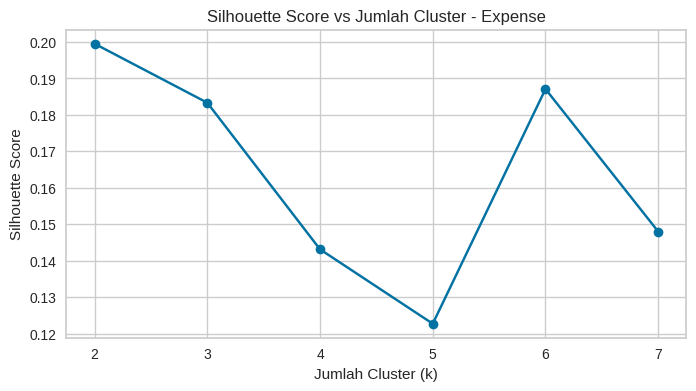

Jumlah cluster terbaik (Expense): 2


In [7]:
# Elbow method untuk expense
k_range = range(2, 8)

scaler_exp = StandardScaler()
X_exp_scaled = scaler_exp.fit_transform(expense)

silhouette_scores_exp = []
for k in k_range:
    km = KMedoids(n_clusters=k, random_state=42)
    km.fit(X_exp_scaled)
    score = silhouette_score(X_exp_scaled, km.labels_)
    silhouette_scores_exp.append(score)

plt.figure(figsize=(8, 4))
plt.plot(k_range, silhouette_scores_exp, marker='o')
plt.title('Silhouette Score vs Jumlah Cluster - Expense')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)
plt.grid(True)
plt.show()

best_k_exp = k_range[silhouette_scores_exp.index(max(silhouette_scores_exp))]
print(f"Jumlah cluster terbaik (Expense): {best_k_exp}")

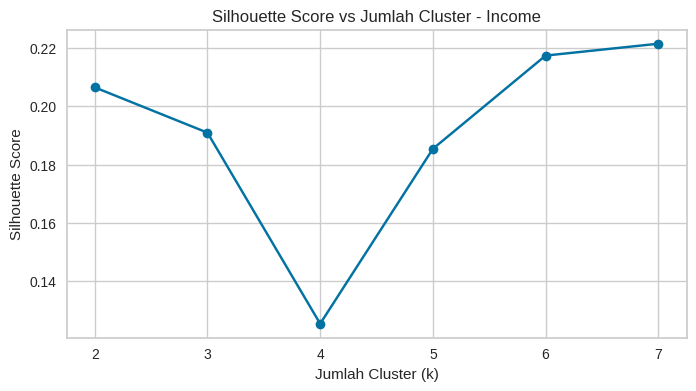

Jumlah cluster terbaik (Income): 7


In [8]:
# Elbow method untuk income
scaler_inc = StandardScaler()
X_inc_scaled = scaler_inc.fit_transform(income)

silhouette_scores_inc = []
for k in k_range:
    km = KMedoids(n_clusters=k, random_state=42)
    km.fit(X_inc_scaled)
    score = silhouette_score(X_inc_scaled, km.labels_)
    silhouette_scores_inc.append(score)

plt.figure(figsize=(8, 4))
plt.plot(k_range, silhouette_scores_inc, marker='o')
plt.title('Silhouette Score vs Jumlah Cluster - Income')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)
plt.grid(True)
plt.show()

best_k_inc = k_range[silhouette_scores_inc.index(max(silhouette_scores_inc))]
print(f"Jumlah cluster terbaik (Income): {best_k_inc}")

In [9]:
# K-Medoids expense
model_kmedoids_exp = KMedoids(n_clusters=2, random_state=42)
model_kmedoids_exp.fit(X_exp_scaled)

labels_exp = model_kmedoids_exp.labels_
expense['Cluster'] = labels_exp

# Auto-relabel: cluster dengan amount rata-rata lebih tinggi = Anomali (1)
cluster_means_exp = expense.groupby('Cluster')['amount'].mean()
anomaly_cluster_exp = cluster_means_exp.idxmax()
expense['Label'] = (expense['Cluster'] == anomaly_cluster_exp).astype(int)

print("Statistik amount per cluster (Expense):")
print(expense.groupby('Cluster')['amount'].agg(['mean', 'min', 'max']).round(0))
print(f"\nCluster {anomaly_cluster_exp} → Anomali (amount lebih tinggi)")
print(f"\nDistribusi Label: {expense['Label'].value_counts().to_dict()}")
print(f"Silhouette Score: {silhouette_score(X_exp_scaled, labels_exp):.4f}")

joblib.dump(model_kmedoids_exp, 'model_kmedoids_expense.pkl')
joblib.dump(scaler_exp, 'scaler_expense.pkl')  # PENTING: simpan scaler juga

Statistik amount per cluster (Expense):
             mean     min       max
Cluster                            
0         55462.0  1000.0  800000.0
1        130245.0   900.0  999000.0

Cluster 1 → Anomali (amount lebih tinggi)

Distribusi Label: {0: 598, 1: 410}
Silhouette Score: 0.1995


['scaler_expense.pkl']

In [10]:
# K-Medoids income
model_kmedoids_inc = KMedoids(n_clusters=2, random_state=42)
model_kmedoids_inc.fit(X_inc_scaled)

labels_inc = model_kmedoids_inc.labels_
income['Cluster'] = labels_inc

cluster_means_inc = income.groupby('Cluster')['amount'].mean()
anomaly_cluster_inc = cluster_means_inc.idxmax()
income['Label'] = (income['Cluster'] == anomaly_cluster_inc).astype(int)

print("Statistik amount per cluster (Income):")
print(income.groupby('Cluster')['amount'].agg(['mean', 'min', 'max']).round(0))
print(f"\nCluster {anomaly_cluster_inc} → Anomali (amount lebih tinggi)")
print(f"\nDistribusi Label: {income['Label'].value_counts().to_dict()}")
print(f"Silhouette Score: {silhouette_score(X_inc_scaled, labels_inc):.4f}")

joblib.dump(model_kmedoids_inc, 'model_kmedoids_income.pkl')
joblib.dump(scaler_inc, 'scaler_income.pkl')

Statistik amount per cluster (Income):
             mean     min       max
Cluster                            
0        121609.0  3000.0  761440.0
1         85299.0     0.0  940000.0

Cluster 0 → Anomali (amount lebih tinggi)

Distribusi Label: {1: 57, 0: 46}
Silhouette Score: 0.2065


['scaler_income.pkl']

In [12]:
# Simpan Hasil Clustering
df_cluster_exp = expense.copy()
df_cluster_inc = income.copy()

df_cluster_exp.to_csv('Financial_Transactions_Cluster_Expense.csv', index=False)
df_cluster_inc.to_csv('Financial_Transactions_Cluster_Income.csv', index=False)

print("Expense cluster saved:", df_cluster_exp.shape)
print("Income cluster saved:", df_cluster_inc.shape)

Expense cluster saved: (1008, 16)
Income cluster saved: (103, 16)


2. Model Klasifikasi

In [13]:
#Train/Test Split Expense
X_exp = df_cluster_exp.drop(columns=['Cluster', 'Label'])
y_exp = df_cluster_exp['Label']

X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(
    X_exp, y_exp, test_size=0.2, random_state=42, stratify=y_exp
)

print("=== EXPENSE ===")
print(f"Total: {len(X_exp)} | Train: {len(X_train_exp)} | Test: {len(X_test_exp)}")
print(f"Label train: {y_train_exp.value_counts().to_dict()}")

=== EXPENSE ===
Total: 1008 | Train: 806 | Test: 202
Label train: {0: 478, 1: 328}


In [14]:
#Train/Test Split Income
X_inc = df_cluster_inc.drop(columns=['Cluster', 'Label'])
y_inc = df_cluster_inc['Label']

X_train_inc, X_test_inc, y_train_inc, y_test_inc = train_test_split(
    X_inc, y_inc, test_size=0.2, random_state=42, stratify=y_inc
)

print("=== INCOME ===")
print(f"Total: {len(X_inc)} | Train: {len(X_train_inc)} | Test: {len(X_test_inc)}")
print(f"Label train: {y_train_inc.value_counts().to_dict()}")

=== INCOME ===
Total: 103 | Train: 82 | Test: 21
Label train: {1: 45, 0: 37}


In [16]:
# Bangun Model Klasifikasi Expense
dt_expense = DecisionTreeClassifier(random_state=42)
dt_expense.fit(X_train_exp, y_train_exp)

print("Decision Tree Expense - Before Tuning:")
print(classification_report(y_test_exp, dt_expense.predict(X_test_exp)))

joblib.dump(dt_expense, 'model_dt_expense.pkl')

Decision Tree Expense - Before Tuning:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       120
           1       1.00      0.94      0.97        82

    accuracy                           0.98       202
   macro avg       0.98      0.97      0.97       202
weighted avg       0.98      0.98      0.98       202



['model_dt_expense.pkl']

In [17]:
# Bangun Model Klasifikasi Income
dt_income = DecisionTreeClassifier(random_state=42)
dt_income.fit(X_train_inc, y_train_inc)

print("Decision Tree Income - Before Tuning:")
print(classification_report(y_test_inc, dt_income.predict(X_test_inc)))

joblib.dump(dt_income, 'model_dt_income.pkl')

Decision Tree Income - Before Tuning:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       1.00      1.00      1.00        12

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21



['model_dt_income.pkl']

## 4. Tuning Model

In [18]:
# Hyperparamter Tuning Expense
params = {
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

tuned_expense = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=params,
    cv=5,
    scoring='accuracy'
)
tuned_expense.fit(X_train_exp, y_train_exp)

print("Best params (Expense):", tuned_expense.best_params_)
print("\nTuned Decision Tree Expense:")
print(classification_report(y_test_exp, tuned_expense.predict(X_test_exp)))

joblib.dump(tuned_expense.best_estimator_, 'model_dt_expense_tuned.pkl')

Best params (Expense): {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}

Tuned Decision Tree Expense:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       120
           1       1.00      0.94      0.97        82

    accuracy                           0.98       202
   macro avg       0.98      0.97      0.97       202
weighted avg       0.98      0.98      0.98       202



['model_dt_expense_tuned.pkl']

In [19]:
# Hyperparamter Tuning Income
tuned_income = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=params,
    cv=5,
    scoring='accuracy'
)
tuned_income.fit(X_train_inc, y_train_inc)

print("Best params (Income):", tuned_income.best_params_)
print("\nTuned Decision Tree Income:")
print(classification_report(y_test_inc, tuned_income.predict(X_test_inc)))

joblib.dump(tuned_income.best_estimator_, 'model_dt_income_tuned.pkl')

Best params (Income): {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}

Tuned Decision Tree Income:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       1.00      1.00      1.00        12

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21



['model_dt_income_tuned.pkl']

## 5. Hasil Klasifikasi

In [20]:
# Expense
df_klasifikasi_exp = df_cluster_exp.copy()
df_klasifikasi_exp['Label_Pred'] = tuned_expense.predict(X_exp)
df_klasifikasi_exp['Status'] = df_klasifikasi_exp['Label_Pred'].map({0: 'Normal', 1: 'Anomali'})

# Income
df_klasifikasi_inc = df_cluster_inc.copy()
df_klasifikasi_inc['Label_Pred'] = tuned_income.predict(X_inc)
df_klasifikasi_inc['Status'] = df_klasifikasi_inc['Label_Pred'].map({0: 'Normal', 1: 'Anomali'})

df_klasifikasi_exp.to_csv('Financial_Transactions_Klasifikasi_Expense.csv', index=False)
df_klasifikasi_inc.to_csv('Financial_Transactions_Klasifikasi_Income.csv', index=False)

print("Expense - distribusi status:")
print(df_klasifikasi_exp['Status'].value_counts())
print("\nIncome - distribusi status:")
print(df_klasifikasi_inc['Status'].value_counts())

Expense - distribusi status:
Status
Normal     603
Anomali    405
Name: count, dtype: int64

Income - distribusi status:
Status
Anomali    57
Normal     46
Name: count, dtype: int64


In [21]:
df_klasifikasi_exp.head()

,amount,year,month,day,category_Bills & Fees,category_Food & Drinks,category_Transport,account_Cash,account_Metro Card,account_Salary Bank,account_Savings Bank,type_EXPENSE,type_INCOME,type_TRANSFER,Cluster,Label,Label_Pred,Status
0,45000.0,2024,8,11,True,False,False,False,False,False,True,True,False,False,0,0,0,Normal
1,40000.0,2024,8,10,False,True,False,True,False,False,False,True,False,False,1,1,1,Anomali
2,10000.0,2024,8,9,False,False,True,True,False,False,False,True,False,False,0,0,0,Normal
3,200000.0,2024,8,7,True,False,False,False,False,False,True,True,False,False,1,1,1,Anomali
4,500000.0,2024,8,4,True,False,False,False,False,False,True,True,False,False,1,1,1,Anomali


In [22]:
df_cluster_inc.head()

,amount,year,month,day,category_Bills & Fees,category_Food & Drinks,category_Transport,account_Cash,account_Metro Card,account_Salary Bank,account_Savings Bank,type_EXPENSE,type_INCOME,type_TRANSFER,Cluster,Label
0,4000.0,2024,8,4,True,False,False,False,False,True,False,False,True,False,0,1
1,0.0,2024,7,20,False,False,True,False,False,False,True,False,True,False,1,0
2,41000.0,2024,7,12,False,False,True,False,False,True,False,False,True,False,1,0
3,71000.0,2024,6,30,False,False,True,False,False,False,True,False,True,False,1,0
4,35000.0,2024,6,17,True,False,False,False,False,True,False,False,True,False,0,1
